# DocLayNet Text Detection `torch.Dataset`
**Author:** Juan Pablo Triana Martinez
**Date:** 2026-03-19

The following is a notebook that showcases the `torch` implementation to create a `torch.Dataset` implementation for performing the following:
1. Create a `torch.Dataset` that is able to get the following arguments:
    - `data_path`: Pathlib path where all the data folder path is located
    - `split_analyze`: String that will determine to get train, val, or test
    - `subset_name`: String name of the subset dataset.
    - `mask_type`: String of what mask to get the following. binary-text for obtaining the extra -> text bboxes masks. semantic-layout obtains the pdf layout bboxes masks.
    - `new_height`: integer for the new H dimension to be resized.
    - `new_width`: integer for the new W dimension to be resized.
2. Create a `torch.Dataloader` to see how it's behaving.

## 1. Let's create the `torch.utils.data.Dataset` for `TextDetectionDataset`

In [11]:
# Import all necessary torch modules
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Import Image and path readings
from PIL import Image
from pathlib import Path
import json

# Import typing and get math masks
from typing import List, Union, Tuple
import math

class TextDetectionDataset(Dataset):
    '''
    Customized class that reads a subset
    Dataset previously extracted,
    and be used for training, validation, and evaluation.
    '''
    def __init__(self,
                data_path:Path,
                split_analyze:str,
                dataset_name:str,
                mask_type:str,
                new_height:int,
                new_width:int,
                transform: Union[transforms.Compose, None]):
        '''
        Args:
            - data_path (Path) : Pathlib path where all the data folder path is located
            - split_analyze (str): String that will determine to get train, val, or test
            - dataset_name (str): String name of the subset dataset.
            - mask_type (str): String of what mask to get the following. binary-text for obtaining the extra -> text bboxes masks.
                semantic-layout obtains the pdf layout bboxes masks.
            - new_height (int): integer for the new H dimension to be resized.
            - new_width (int): integer for the new W dimension to be resized.
            - transform (None or transforms.Compose): torchvision.transforms.Compose that applies vision transformations,
                # NOTE: if set to None, a new transform set with torch.toTensor() + torch.Resize(new_height, new_width) would be done.
                and if you add customized of transform, MAKE SURE new height and new width are set the same dimensions you want in your
                desired transform, otherwise the bboxes would be scaled improperly.
        '''

        super().__init__()
        
        # let's assign the data_path and see if it exists
        assert data_path.exists(), "The data folder doesn't exist, please check that it exists"
        self.data_path = data_path

        # Let's assign the dataset name and see that the subset folder works
        assert isinstance(dataset_name, str), "Add a valid string name for the datasetname"
        self.dataset_name = dataset_name

        self.subset_data_path = data_path / dataset_name
        assert self.subset_data_path.exists(), "Subset data folder doesn't exist, which means it doesn't"

        assert split_analyze in ["train", "val", "test"], "Please type a valud split, either train, val, or test"
        self.split = split_analyze

        assert mask_type in ["binary-text", "semantic-layout"], "Please, write either binary-text or semantic-layout"
        self.mask_type = mask_type

        assert isinstance(new_height, int) and new_height <= 1025, "Assign a valid integer for the new_height"
        self.new_height = new_height

        # Bug fix 4: assertion was checking new_height instead of new_width
        assert isinstance(new_width, int) and new_width <= 1025, "Assign a valid integer for the new_width"
        self.new_width = new_width

        # Let's construct the dictionaroes of DocLayNet_core to read from
        json_split = split_analyze + ".json"
        json_path = self.subset_data_path / "COCO" / json_split
        with open(json_path, "r") as f:
            coco_dict = json.load(f)

        # if mask_type is semantic-layout, assign the JSON extra path
        self.extra_json_folder_path = self.data_path / self.dataset_name / "JSON"
        assert self.extra_json_folder_path.exists(), "Semantic-layout mask requested, but JSON folder from extra information is not inside dataset, please check"

        # Obtain all neccssary COCO json variables
        self.coco_images = coco_dict["images"]
        self.coco_annotations = coco_dict["annotations"]
        self.coco_categories = coco_dict["categories"]

        # Set the transform
        if transform:
            self.transform = transform
        else:
            self.transform = transforms.Compose([
                transforms.Resize((new_height, new_width)),
                transforms.ToTensor()
            ])

    def get_mask(self, 
            img_name:str,
            annotations: List[dict[str, Union[int, str]]]) -> Tuple[torch.Tensor, torch.Tensor]:
        '''
        Instance method that will return the image tensor and its corresponding mask tensor.
        '''

        # Let's instantiate the mask
        semantic_mask = torch.zeros((1, self.new_height, self.new_width), dtype = torch.float32)

        # Let's get the image path directly to the PNG folder
        img_path = self.subset_data_path / "PNG" / img_name
        pil_image = Image.open(img_path).convert("RGB")
        
        # Bug fix 2: PIL .size returns (width, height), not (height, width)
        original_width, original_height = pil_image.size

        # Convert to tensor
        tensor_image = self.transform(pil_image)

        y_scale = self.new_height / original_height
        x_scale = self.new_width / original_width

        # Now let's get the mask
        for ann in annotations:
            x, y, w, h = ann["bbox"] # [x, y, w, h]

            # Now let's scale them properly
            x = x * x_scale
            y = y * y_scale 
            w = w * x_scale
            h = h * y_scale

            # Now let's floor them to remove decimals
            xmin = int(math.floor(x))
            ymin = int(math.floor(y))
            xmax = int(math.ceil(x + w))
            ymax = int(math.ceil(y + h))

            # Bug fix 3: clip against the new (resized) dimensions, not the original ones
            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(self.new_width - 1, xmax)
            ymax = min(self.new_height - 1, ymax)

            if self.mask_type == "semantic-layout":
                # Let's get the supercategory id, i.e: Caption, Footnote, etc.
                cat_id = ann["category_id"]
                semantic_mask[0, ymin:ymax+1, xmin:xmax+1] = cat_id
            else:
                semantic_mask[0, ymin:ymax+1, xmin:xmax+1] = 1.0

        # Bug fix 1: return was inside the for loop — moved outside so all annotations are drawn
        return tensor_image, semantic_mask

    def __len__(self):
        '''
        Returns the total number of samples
        '''
        return len(self.coco_images)

    def __getitem__(self, idx):
        '''
        Returns one sample of data, data and asmk (X, X_mask)
        '''
        # Get the selected image and image id
        sel_coco_image_dict = self.coco_images[idx]
        image_id = sel_coco_image_dict["id"]
        img_name = sel_coco_image_dict["file_name"]

        # Get the annotations
        if self.mask_type == "semantic-layout":
            sel_annotations = [annotation for annotation in self.coco_annotations if annotation["image_id"] == image_id]

        if self.mask_type == "binary-text":
            hash_name = sel_coco_image_dict["file_name"].split(".")[0]
            
            # extra_json_name to access inside JSON folder
            extra_json_name = hash_name + ".json"

            with open(self.extra_json_folder_path / extra_json_name, "r") as f:
                extra_dict = json.load(f)
            
            # Select the annotations pertinent to cells where text is located
            sel_annotations = extra_dict["cells"]
        
        # Let's get the image and mask
        sel_img, sel_mask = self.get_mask(
            img_name=img_name,
            annotations=sel_annotations)

        return sel_img, sel_mask, sel_coco_image_dict


### Let's test it out the `TextDetectionDataset`

In [12]:
# Let's get the data path and dataset name
data_path_local = Path().cwd().parent / "data"
dataset_name_local = "test_subsample_seed_42"

In [25]:
text_detection_dataset = TextDetectionDataset(data_path = data_path_local,
                split_analyze = "train",
                dataset_name = dataset_name_local,
                mask_type = "semantic-layout",
                new_height = 1024,
                new_width = 1024,
                transform=None)

In [26]:
test_img, test_mask, test_img_metadata = text_detection_dataset[3]

{'id': 21586, 'width': 1025, 'height': 1025, 'file_name': '645f3c265aa08acf4e75e43983c2656c7b4f633b0c5959490d5c772b7dddde5a.png', 'collection': 'ann_reports_10_14_fancy', 'doc_name': 'NYSE_HL_2012.pdf', 'page_no': 78, 'precedence': 0, 'doc_category': 'financial_reports'}


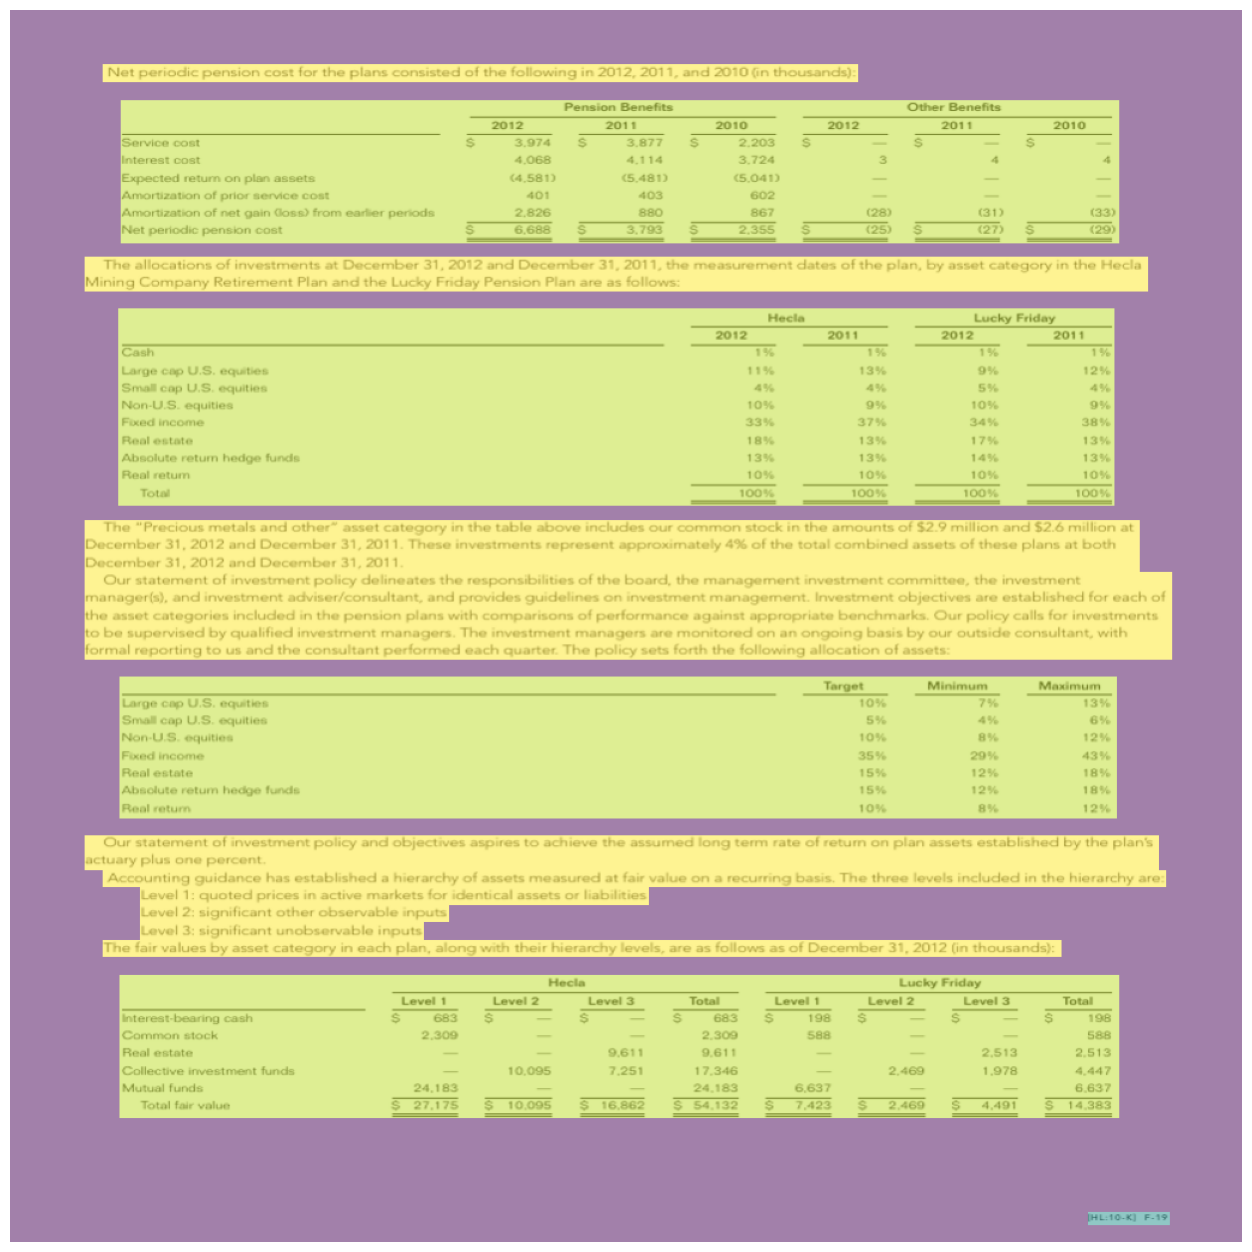

In [27]:
import matplotlib.pyplot as plt
print(test_img_metadata)
img = test_img.permute(1, 2, 0).cpu()
mask = test_mask.permute(1, 2, 0).cpu()

plt.figure(figsize=(16, 16))
plt.imshow(img)
plt.imshow(mask, alpha=0.5,)  # alpha controls transparency
plt.axis("off")
plt.show()